In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from chronos import Chronos2Pipeline

In [2]:
candidate_paths = [
    Path("data_final/load_1.csv"),
    Path("data final/load_1.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("`load_1.csv`를 찾지 못했습니다. `processed_data/` 경로를 확인하세요.")

df = pd.read_csv(data_path, parse_dates=["time"]).sort_values("time").reset_index(drop=True)
df.head()

,time,load,temp,rhum,dew_point,apparent_temp,precip,rain,snow,press,...,pca_embedding_22,pca_embedding_23,pca_embedding_24,pca_embedding_25,pca_embedding_26,pca_embedding_27,pca_embedding_28,pca_embedding_29,pca_embedding_30,pca_embedding_31
0,2012-01-02 00:00:00,185962,-5.074,66.099730,-10.424,-9.024538,0.0,0.0,0.0,1014.72950,...,-0.233154,-0.213379,0.094666,-0.102417,-0.031311,0.031158,0.014641,-0.032928,-0.294922,-0.065369
1,2012-01-02 01:00:00,184730,-4.924,65.613570,-10.374,-8.855997,0.0,0.0,0.0,1015.13153,...,-0.233154,-0.213379,0.094666,-0.102417,-0.031372,0.031052,0.014694,-0.033081,-0.294922,-0.065369
2,2012-01-02 02:00:00,181090,-4.824,64.606460,-10.474,-8.649612,0.0,0.0,0.0,1015.23456,...,-0.233154,-0.213379,0.094666,-0.102417,-0.031311,0.031158,0.014641,-0.032928,-0.294922,-0.065369
3,2012-01-02 03:00:00,186018,-4.724,64.120810,-10.474,-8.434195,0.0,0.0,0.0,1015.53534,...,-0.233154,-0.213379,0.094666,-0.102417,-0.031372,0.031052,0.014694,-0.033081,-0.294922,-0.065369
4,2012-01-02 04:00:00,186788,-5.524,67.853386,-10.524,-9.353552,0.0,0.0,0.0,1015.70010,...,-0.233154,-0.213379,0.094666,-0.102417,-0.031311,0.031158,0.014641,-0.032928,-0.294922,-0.065369


In [3]:
prediction_length = 72
time_col = "time"
target_col = "load"
covariate_cols = [col for col in df.columns if col not in [time_col, target_col]]

# 이 데이터는 주말 구간이 비어 있어 calendar-based frequency를 바로 추론할 수 없습니다.
# 그래서 Chronos-2에는 timestamp 대신 관측 순서 기준 배열 입력을 사용합니다.
train_df = df.iloc[:-prediction_length].copy()
test_df = df.iloc[-prediction_length:].copy()

task = {
    "target": train_df[target_col].to_numpy(dtype="float32"),
    "past_covariates": {
        col: train_df[col].to_numpy(dtype="float32") for col in covariate_cols
    },
    "future_covariates": {
        col: test_df[col].to_numpy(dtype="float32") for col in covariate_cols
    },
}

print(f"data_path: {data_path}")
print(f"rows: {len(df):,}, train: {len(train_df):,}, test: {len(test_df):,}")
print(f"range: {df[time_col].min()} -> {df[time_col].max()}")
print(f"inferred_freq: {pd.infer_freq(df[time_col])}")
print(f"covariates: {len(covariate_cols)}")
task["target"][:5], list(task["past_covariates"].keys())[:5]

data_path: data_final/load_1.csv
rows: 17,760, train: 17,688, test: 72
range: 2012-01-02 00:00:00 -> 2014-12-31 23:00:00
inferred_freq: None
covariates: 70


(array([185962., 184730., 181090., 186018., 186788.], dtype=float32),
 ['temp', 'rhum', 'dew_point', 'apparent_temp', 'precip'])

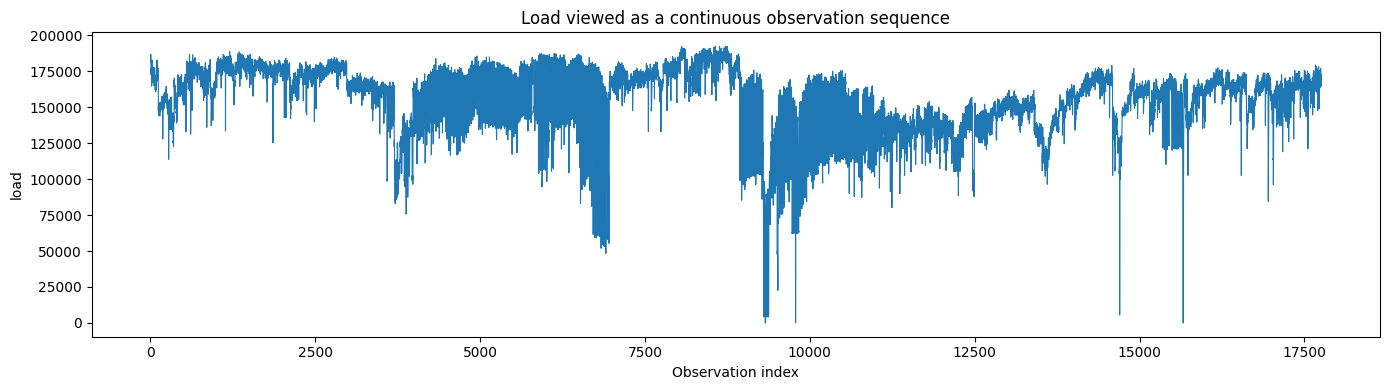

,time,obs_idx,load
0,2012-01-02 00:00:00,0,185962
1,2012-01-02 01:00:00,1,184730
2,2012-01-02 02:00:00,2,181090
3,2012-01-02 03:00:00,3,186018
4,2012-01-02 04:00:00,4,186788


In [4]:
# 실제 시각축(time) 대신 관측 순서(obs_idx)로 이어서 보기
df_plot = df.copy()
df_plot["obs_idx"] = range(len(df_plot))

plt.figure(figsize=(14, 4))
plt.plot(df_plot["obs_idx"], df_plot[target_col], linewidth=0.8)
plt.title("Load viewed as a continuous observation sequence")
plt.xlabel("Observation index")
plt.ylabel(target_col)
plt.tight_layout()
plt.show()

df_plot[[time_col, "obs_idx", target_col]].head()

device=cuda, MAE=4,757.78, RMSE=5,916.24


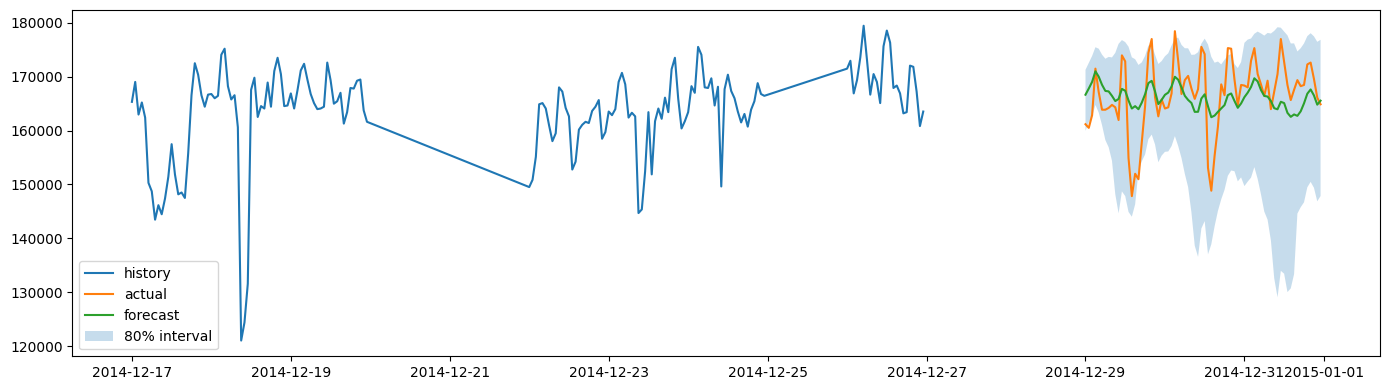

,timestamp,actual,predictions,0.1,0.5,0.9
0,2014-12-29 00:00:00,161168,166638.406250,159948.78125,166638.406250,171253.93750
1,2014-12-29 01:00:00,160496,167791.671875,161540.59375,167791.671875,172537.12500
2,2014-12-29 02:00:00,162848,169014.203125,162532.62500,169014.203125,173817.18750
3,2014-12-29 03:00:00,171472,170979.375000,164742.21875,170979.375000,175441.43750
4,2014-12-29 04:00:00,167104,169976.203125,163327.00000,169976.203125,175168.40625


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)

quantile_levels = [0.1, 0.5, 0.9]
quantiles, mean = pipeline.predict_quantiles(
    [task],
    prediction_length=prediction_length,
    quantile_levels=quantile_levels,
)

q = quantiles[0].squeeze(0).cpu().numpy()
pred = mean[0].squeeze(0).cpu().numpy()

result = pd.DataFrame({
    "timestamp": test_df[time_col].to_numpy(),
    "actual": test_df[target_col].to_numpy(),
    "predictions": pred,
    "0.1": q[:, 0],
    "0.5": q[:, 1],
    "0.9": q[:, 2],
})

mae = (result["predictions"] - result["actual"]).abs().mean()
rmse = ((result["predictions"] - result["actual"]) ** 2).mean() ** 0.5
print(f"device={device}, MAE={mae:,.2f}, RMSE={rmse:,.2f}")

plt.figure(figsize=(14, 4))
plt.plot(train_df[time_col].tail(24 * 7), train_df[target_col].tail(24 * 7), label="history")
plt.plot(result["timestamp"], result["actual"], label="actual")
plt.plot(result["timestamp"], result["predictions"], label="forecast")
plt.fill_between(result["timestamp"], result["0.1"], result["0.9"], alpha=0.25, label="80% interval")
plt.legend()
plt.tight_layout()
plt.show()

result.head()

In [6]:
from chronos2_multiseries_finetune import (
    build_finetune_inputs,
    extract_prediction_attention,
    extract_window_attention,
    extract_window_attentions,
    finetune_pipeline,
    load_series_splits,
    rolling_evaluate,
    summarize_results,
    summarize_window_attentions,
    load_finetuned_pipeline
)

In [7]:
TRAIN_END = "2012-12-31 23:00:00"
TEST_START = "2013-01-01 00:00:00"
PREDICTION_LENGTH = 1
WINDOW_STRIDE = 1

# 전체 실험은 둘 다 None으로 두면 됩니다.
# 처음 확인할 때만 예: MAX_SERIES = 20, MAX_WINDOWS = 200
MAX_SERIES = None
MAX_WINDOWS = None

FINETUNE_MODE = "lora"
NUM_STEPS = 30000
FT_BATCH_SIZE = 64
PRED_BATCH_SIZE = 64
CONTEXT_LENGTH = 168
OUTPUT_DIR = "outputs/LOAD_ONLY_1step"

# 1-step 전체 결과는 메모리에 한 번에 올리지 않고 series별로 저장합니다.
EVAL_OUTPUT_DIR = Path("outputs/LOAD_ONLY_1step_eval_by_series")
EVAL_OVERWRITE = False
COMBINE_ALL_RESULTS = False
COMBINED_RESULTS_PATH = Path("PREDICTION_RESULTS/1step_load_only.csv")


In [8]:
series_splits, covariate_cols = load_series_splits(
    data_dir="data_load_only",
    train_end=TRAIN_END,
    test_start=TEST_START,
    max_series=MAX_SERIES,
    use_covariates=True,
)

train_inputs = build_finetune_inputs(series_splits)

def count_series_windows(split, prediction_length, window_stride):
    max_start = len(split.test_target) - prediction_length
    if max_start < 0:
        return 0
    return max_start // window_stride + 1

total_test_windows = sum(
    count_series_windows(split, PREDICTION_LENGTH, WINDOW_STRIDE)
    for split in series_splits
)
total_test_rows = total_test_windows * PREDICTION_LENGTH

pd.Series(
    {
        "n_series": len(series_splits),
        "n_covariates": len(covariate_cols),
        "train_min_len": min(len(split.train_target) for split in series_splits),
        "train_max_len": max(len(split.train_target) for split in series_splits),
        "test_min_len": min(len(split.test_target) for split in series_splits),
        "test_max_len": max(len(split.test_target) for split in series_splits),
        "total_1step_windows": total_test_windows,
        "total_result_rows": total_test_rows,
    }
)


n_series                   763
n_covariates                 0
train_min_len             1848
train_max_len             6048
test_min_len              7704
test_max_len             11928
total_1step_windows    8994264
total_result_rows      8994264
dtype: int64

In [9]:
finetuned_pipeline, ft_device = finetune_pipeline(
    train_inputs=train_inputs,
    prediction_length=PREDICTION_LENGTH,
    finetune_mode=FINETUNE_MODE,
    num_steps=NUM_STEPS,
    batch_size=FT_BATCH_SIZE,
    context_length=CONTEXT_LENGTH,
    output_dir=OUTPUT_DIR,
)

print(ft_device)

Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
3000,0.147400
6000,0.144000


KeyboardInterrupt: 

In [10]:
reloaded_pipeline, device = load_finetuned_pipeline(
    "outputs/LOAD_ONLY_1step/finetuned-ckpt"
)

print(device)

cuda


In [11]:
file_ids = [f"load_{i}" for i in range(1, 764)]

# 일부 파일만 먼저 확인하려면 예: ["load_1", "load_26"]
EVAL_SERIES_IDS = file_ids

pd.Series(
    {
        "n_eval_series": len(EVAL_SERIES_IDS),
        "eval_output_dir": str(EVAL_OUTPUT_DIR),
        "overwrite_existing": EVAL_OVERWRITE,
        "combine_all_results": COMBINE_ALL_RESULTS,
    }
)


n_eval_series                                             763
eval_output_dir        outputs/LOAD_ONLY_1step_eval_by_series
overwrite_existing                                      False
combine_all_results                                     False
dtype: object

In [12]:
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

series_eval_summary_rows = []

for idx, series_id in enumerate(EVAL_SERIES_IDS, start=1):
    result_path = EVAL_OUTPUT_DIR / f"{series_id}.csv"

    if result_path.exists() and not EVAL_OVERWRITE:
        series_result = pd.read_csv(result_path, parse_dates=["timestamp"])
        status = "loaded_existing"
    else:
        series_result = rolling_evaluate(
            pipeline=reloaded_pipeline,
            series_splits=series_splits,
            prediction_length=PREDICTION_LENGTH,
            batch_size=PRED_BATCH_SIZE,
            window_stride=WINDOW_STRIDE,
            max_windows=MAX_WINDOWS,
            max_context=CONTEXT_LENGTH,
            series_ids=[series_id],
        )
        series_result.to_csv(result_path, index=False)
        status = "evaluated"

    if series_result.empty:
        summary_row = {
            "series_id": series_id,
            "status": status,
            "n_rows": 0,
            "n_windows": 0,
            "MAE": float("nan"),
            "RMSE": float("nan"),
            "MAPE": float("nan"),
            "MPE": float("nan"),
            "result_path": str(result_path),
        }
    else:
        err = series_result["predictions"] - series_result["actual"]
        nonzero_actual = series_result["actual"].replace(0, float("nan")).astype("float64")
        pct_err = err / nonzero_actual
        summary_row = {
            "series_id": series_id,
            "status": status,
            "n_rows": len(series_result),
            "n_windows": series_result["window_idx"].nunique(),
            "MAE": err.abs().mean(),
            "RMSE": (err.pow(2).mean()) ** 0.5,
            "MAPE": pct_err.abs().mean() * 100,
            "MPE": pct_err.mean() * 100,
            "result_path": str(result_path),
        }

    series_eval_summary_rows.append(summary_row)

    if idx % 25 == 0 or idx == len(EVAL_SERIES_IDS):
        print(f"[{idx}/{len(EVAL_SERIES_IDS)}] processed")

series_eval_summary = pd.DataFrame(series_eval_summary_rows)
series_eval_summary.to_csv(EVAL_OUTPUT_DIR / "_summary.csv", index=False)
series_eval_summary.head()


[25/763] processed
[50/763] processed
[75/763] processed
[100/763] processed
[125/763] processed
[150/763] processed
[175/763] processed
[200/763] processed
[225/763] processed
[250/763] processed
[275/763] processed
[300/763] processed
[325/763] processed
[350/763] processed
[375/763] processed
[400/763] processed
[425/763] processed
[450/763] processed
[475/763] processed
[500/763] processed
[525/763] processed
[550/763] processed
[575/763] processed
[600/763] processed
[625/763] processed
[650/763] processed
[675/763] processed
[700/763] processed
[725/763] processed
[750/763] processed
[763/763] processed


,series_id,status,n_rows,n_windows,MAE,RMSE,MAPE,MPE,result_path
0,load_1,evaluated,11784,11784,3074.709473,5152.669922,5.320338,3.252903,outputs/LOAD_ONLY_1step_eval_by_series/load_1.csv
1,load_2,evaluated,11448,11448,20.986536,36.672577,13.161474,7.721003,outputs/LOAD_ONLY_1step_eval_by_series/load_2.csv
2,load_3,evaluated,11904,11904,7.576694,13.663780,17.510553,10.568015,outputs/LOAD_ONLY_1step_eval_by_series/load_3.csv
3,load_4,evaluated,11688,11688,6.600469,11.405846,2.327666,0.075395,outputs/LOAD_ONLY_1step_eval_by_series/load_4.csv
4,load_5,evaluated,11904,11904,90.004456,152.754745,3.207942,0.428896,outputs/LOAD_ONLY_1step_eval_by_series/load_5.csv


In [13]:
summary = pd.Series(
    {
        "n_series_processed": int(series_eval_summary["series_id"].nunique()),
        "total_rows_saved": int(series_eval_summary["n_rows"].sum()),
        "mean_series_mae": series_eval_summary["MAE"].mean(),
        "mean_series_rmse": series_eval_summary["RMSE"].mean(),
        "mean_series_mape": series_eval_summary["MAPE"].mean(),
    }
)
print(summary)

if COMBINE_ALL_RESULTS:
    result_files = sorted(EVAL_OUTPUT_DIR.glob("load_*.csv"))
    results = pd.concat(
        [pd.read_csv(path, parse_dates=["timestamp"]) for path in result_files],
        ignore_index=True,
    )
    COMBINED_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    results.to_csv(COMBINED_RESULTS_PATH, index=False)
    print(f"combined results saved to {COMBINED_RESULTS_PATH}")
else:
    print("combined results were skipped to avoid high memory usage")


n_series_processed    7.630000e+02
total_rows_saved      8.994264e+06
mean_series_mae       2.433537e+02
mean_series_rmse      4.120563e+02
mean_series_mape      1.125013e+01
dtype: float64
combined results were skipped to avoid high memory usage


In [14]:
final_metrics = series_eval_summary.set_index("series_id")[["MAE", "MAPE", "MPE"]].copy()

print("--- 각 Series별 요약 통계 ---")
print(final_metrics.describe())

print("\n--- 성능 저하 Series Top 5 (MAPE 기준) ---")
print(final_metrics.sort_values(by="MAPE", ascending=False).head(5))

summary_output_path = EVAL_OUTPUT_DIR / "metrics_by_series.csv"
final_metrics.to_csv(summary_output_path)
print(f"saved metrics to {summary_output_path}")


--- 각 Series별 요약 통계 ---
                MAE        MAPE         MPE
count    763.000000  763.000000  763.000000
mean     243.353683   11.250129    5.684208
std     1113.971558   26.549501   24.011170
min        0.409004    0.168979   -1.517908
25%       13.525014    3.257119    0.206006
50%       39.213753    5.798377    0.954362
75%      103.814011   10.988650    3.286741
max    16158.780273  593.360639  560.175114

--- 성능 저하 Series Top 5 (MAPE 기준) ---
                   MAE        MAPE         MPE
series_id                                     
load_157    157.975632  593.360639  560.175114
load_371   1067.132080  197.923348  156.050576
load_51      13.776575  196.913885  152.742435
load_264     25.116377   98.182877   97.781680
load_750     94.023308   92.933049   80.820767
saved metrics to outputs/LOAD_ONLY_1step_eval_by_series/metrics_by_series.csv


In [ ]:
#results = pd.read_csv('outputs/chronos2_ft_news_cnt_24step.csv')

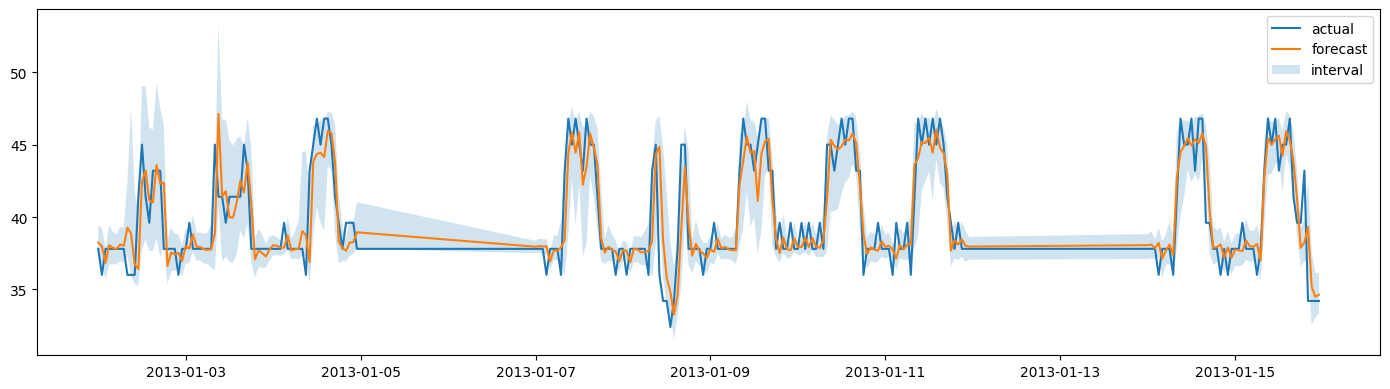

In [ ]:
file_num = 7
end = 24 * 10
series_result_path = EVAL_OUTPUT_DIR / f"load_{file_num}.csv"

result = pd.read_csv(series_result_path, parse_dates=["timestamp"]).iloc[:end].copy()

plt.figure(figsize=(14, 4))
plt.plot(result["timestamp"], result["actual"], label="actual")
plt.plot(result["timestamp"], result["predictions"], label="forecast")
if {"0.1", "0.9"}.issubset(result.columns):
    plt.fill_between(result["timestamp"], result["0.1"], result["0.9"], alpha=0.2, label="interval")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print(f"per-series results are stored in {EVAL_OUTPUT_DIR}")
print(f"per-series summary is stored in {EVAL_OUTPUT_DIR / "_summary.csv"}")
if COMBINE_ALL_RESULTS:
    print(f"combined results are stored in {COMBINED_RESULTS_PATH}")
else:
    print("set COMBINE_ALL_RESULTS = True if you really need a single merged csv")
